# Track A, Part B, Data Handling (your turn)
Fill the `# TODO` lines, the **Your choice** cells, and the **Observe** cells. Cells without a prompt are demos to run. For every choice ask: would this be available when we forecast?

In [1]:
from google.colab import files
import os
import shutil

os.makedirs("/content/data", exist_ok=True)

uploaded = files.upload()

for filename in uploaded:
    destination = f"/content/data/{filename}"

    if os.path.exists(destination):
        os.remove(destination)

    shutil.move(filename, destination)

print("Uploaded files:", os.listdir("/content/data"))

Saving energy_dataset.csv to energy_dataset.csv
Saving weather_features.csv to weather_features.csv
Uploaded files: ['energy_dataset.csv', 'weather_features.csv']


In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.titleweight": "bold"})
BLUE, ORANGE, GREY = "#1f6feb", "#fb8500", "#9aa0a6"
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"; IMG = ROOT / "images" / "partB"; IMG.mkdir(parents=True, exist_ok=True)
(ROOT / "models").mkdir(exist_ok=True)

## 1. Load and protect the raw data
Never overwrite the raw files. Load once, then work on copies.

In [3]:
energy_raw = pd.read_csv(DATA / "energy_dataset.csv")
weather_raw = pd.read_csv(DATA / "weather_features.csv")
energy, weather = energy_raw.copy(), weather_raw.copy()
print("energy", energy.shape, "| weather", weather.shape)

energy (35064, 29) | weather (178396, 17)


## 2. Timeline integrity
Parse to UTC, sort, and check the hours are regular. "Same hour yesterday" only means something if yesterday's hour is there.

In [4]:
energy["time"]  = pd.to_datetime(energy["time"], utc=True, errors="coerce")
weather["time"] = pd.to_datetime(weather["dt_iso"], utc=True, errors="coerce")
energy = energy.sort_values("time").reset_index(drop=True)
full = pd.date_range(energy["time"].min(), energy["time"].max(), freq="h", tz="UTC")
print("duplicate hours:", int(energy["time"].duplicated().sum()),
      "| missing hours:", len(full.difference(pd.DatetimeIndex(energy["time"]))))

duplicate hours: 0 | missing hours: 0


**Observe.** Are there duplicate or missing hours? Why would a single missing hour break a t-24 lag?

**Answer:** There are no duplicate or missing hourly timestamps, so the timeline is regular. A missing hour would cause a t-24 lag to point to the wrong observation because shifting by 24 rows would no longer represent exactly 24 hours earlier.

## 3. Target, reference, horizon
**Target** `total load actual` (MW). **Reference** `total load forecast`, a forecast already in the data, kept for comparison only. **Horizon** 24 hours.

In [5]:
TARGET, REFERENCE, HORIZON = "total load actual", "total load forecast", 24
p = energy[[TARGET, REFERENCE]].dropna()
mape = ((p[REFERENCE] - p[TARGET]).abs() / p[TARGET]).mean() * 100
print(f"reference forecast MAPE = {mape:.2f}%  |  target missing values: {int(energy[TARGET].isna().sum())}")

reference forecast MAPE = 1.10%  |  target missing values: 36


**Observe.** How strong is the provided forecast? Should we use it as a feature? Why not?

**Answer:** The provided forecast is strong because its MAPE is approximately 1.10%. However, it should not be used as an input feature because it is already a professional forecast of the target and could cause target leakage. It should only be kept as a reference benchmark for comparing our model.

## 4. Drop dead columns
**Your turn:** find the fully empty and the always zero columns. Trap: an all-NaN column has an empty `dropna()`, and `(empty == 0).all()` returns `True`, so exclude the empty ones from the zero test.

In [6]:
empty_cols = [c for c in energy.columns if energy[c].isna().all()]

num = energy.select_dtypes("number")

zero_cols = [
    c for c in num.columns
    if c not in empty_cols and (num[c].dropna() == 0).all()
]

energy = energy.drop(columns=empty_cols + zero_cols)

print("Fully empty columns:", empty_cols)
print("Always-zero columns:", zero_cols)
print("dropped", len(empty_cols + zero_cols), "->", energy.shape[1], "cols")

Fully empty columns: ['generation hydro pumped storage aggregated', 'forecast wind offshore eday ahead']
Always-zero columns: ['generation fossil coal-derived gas', 'generation fossil oil shale', 'generation fossil peat', 'generation geothermal', 'generation marine', 'generation wind offshore']
dropped 8 -> 21 cols


## 5. Weather to one row per hour, then merge
National target, so we need one weather row per hour. **Your turn:** aggregate across cities (one row per hour), then merge on `time`.

In [7]:
weather["city_name"] = weather["city_name"].str.strip()
weather = weather.drop_duplicates(subset=["time", "city_name"])

wnum = [
    c for c in weather.select_dtypes("number").columns
    if c != "weather_id"
]

# Average the weather readings across all cities for each hour
weather_agg = weather.groupby("time", as_index=False)[wnum].mean()

# Convert temperatures from Kelvin to Celsius
for c in ["temp", "temp_min", "temp_max"]:
    weather_agg[c] -= 273.15

# Join the energy and weather data using the timestamp
df = energy.merge(weather_agg, on="time", how="left")

print("df", df.shape)

df (35064, 32)


## 6. Look first: distributions and box plots
Before counting missing values, we look. A box plot shows the spread and what reads as extreme. A profile by hour shows whether an extreme value is just a normal peak.

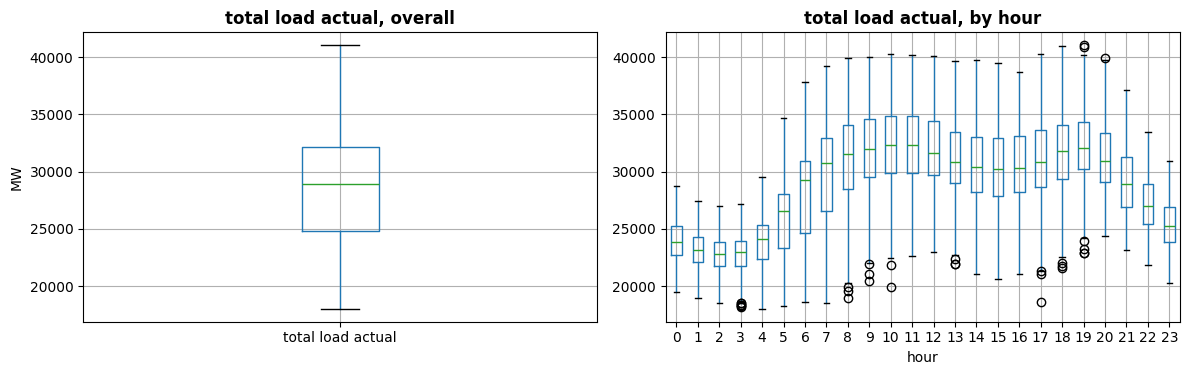

In [8]:
df["hour"] = df["time"].dt.hour
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df.boxplot(column=TARGET, ax=ax[0]); ax[0].set_title("total load actual, overall"); ax[0].set_ylabel("MW")
df.boxplot(column=TARGET, by="hour", ax=ax[1]); ax[1].set_title("total load actual, by hour"); ax[1].set_xlabel("hour")
plt.suptitle(""); fig.tight_layout(); fig.savefig(IMG / "box_target.png", dpi=130); plt.show()

**Observe.** Are the high target values errors, or normal peaks? Look at the by-hour view before deciding.

**Answer:** The high and low target values appear to be normal electricity-demand peaks and troughs rather than errors. The by-hour box plot shows that demand naturally changes depending on the time of day, so values that look unusual in the overall box plot may be reasonable for a specific hour. Therefore, the target values should not be removed or clipped based only on the overall box plot.

## 7. Missing values: where, how much, isolated or clustered
Now we count, and we look at when the gaps happen, because in a time series timing matters as much as quantity.

total load actual                              0.10
generation hydro pumped storage consumption    0.05
generation biomass                             0.05
generation hydro run-of-river and poundage     0.05
generation fossil oil                          0.05
generation waste                               0.05
generation fossil brown coal/lignite           0.05
generation fossil hard coal                    0.05
generation fossil gas                          0.05
generation hydro water reservoir               0.05
generation other                               0.05
generation solar                               0.05
generation other renewable                     0.05
generation wind onshore                        0.05
generation nuclear                             0.05


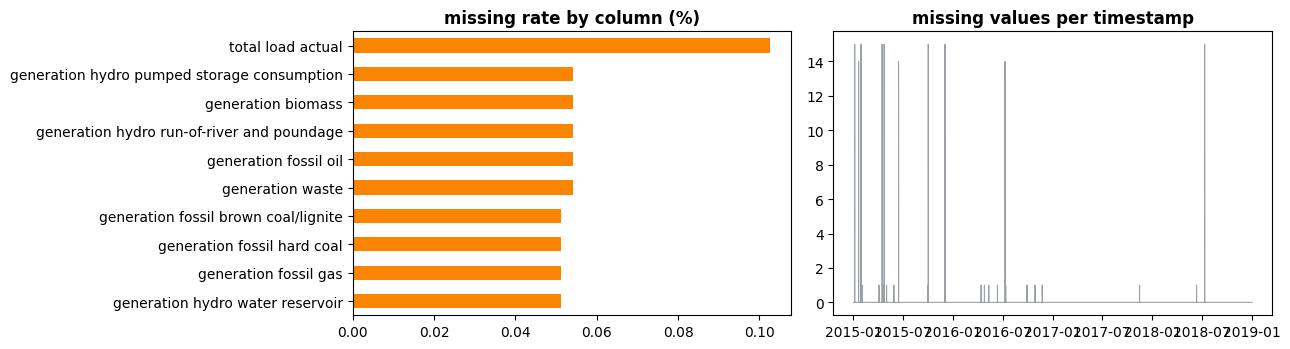

In [9]:
rate = df.isna().mean() * 100; rate = rate[rate > 0].sort_values(ascending=False)
print(rate.round(2).to_string())
miss_t = df.set_index("time").isna().sum(axis=1)
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
rate.head(10).iloc[::-1].plot.barh(ax=ax[0], color=ORANGE); ax[0].set_title("missing rate by column (%)")
ax[1].plot(miss_t.index, miss_t.values, color=GREY, lw=0.8); ax[1].set_title("missing values per timestamp")
fig.tight_layout(); fig.savefig(IMG / "missing.png", dpi=130); plt.show()

**Observe.** How many gaps, and are they isolated spikes or solid blocks? What does that imply for how we fill them?

**Answer:** The missing rates are very low, with total load actual having the highest missing rate at about 0.10%, while several generation columns have around 0.05% missing values. The gaps appear mainly as isolated spikes at certain timestamps rather than long continuous blocks. Some timestamps have many columns missing at the same time. Since the gaps are short and isolated, time interpolation is suitable for continuous historical features because it estimates values using nearby observations.

## 8. Choosing an imputation method
 Each method fits a situation.

| Method | Good when | Watch out |
|---|---|---|
| median or mean | numeric feature, order does not matter | the mean is pulled by outliers |
| forward fill (ffill) | short gap in a continuous signal | repeats the last past value, fine |
| time interpolation | short isolated gaps, smooth signal | uses neighbours, a mild assumption |
| back fill (bfill) | never in forecasting | uses the future, forbidden |
| drop the column | the column is almost all empty | loses signal |
| flag and exclude | the target, which is a label | shrinks the labelled set |

Run the example, then make your choice below.

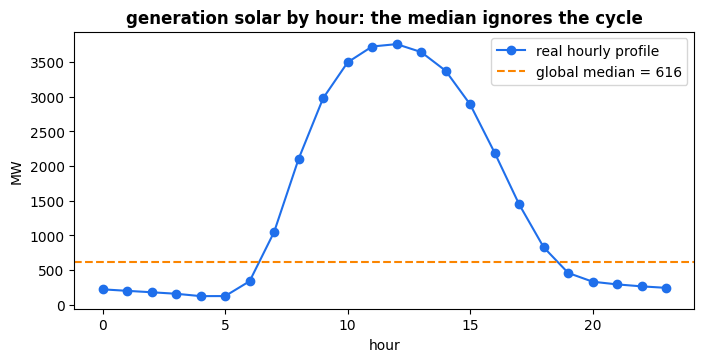

In [10]:
prof = df.groupby("hour")["generation solar"].mean()
gmed = df["generation solar"].median()
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(prof.index, prof.values, marker="o", color=BLUE, label="real hourly profile")
ax.axhline(gmed, color=ORANGE, ls="--", label=f"global median = {gmed:.0f}")
ax.set_title("generation solar by hour: the median ignores the cycle")
ax.set_xlabel("hour"); ax.set_ylabel("MW"); ax.legend()
fig.savefig(IMG / "impute_choice.png", dpi=130); plt.show()

**Your choice.**
Generation features: method = time interpolation, because the missing values are isolated and the generation data follows a smooth time-based pattern. A global median would ignore the strong daily cycle, especially for solar generation.

Production pipeline: method = forward fill, because the system scores one row at a time and only past information is available. Forward fill uses the latest known value and does not use future data.

## 9. The target is special
The target is a label. Naively imputing it fabricates demand that never happened. Dropping its 36 rows breaks the hourly continuity, so lags would misalign.
**Your turn:** propose a strategy that keeps the series regular for features AND never lets an invented value be trained on or scored. Then fill the `# TODO`.

In [11]:
df["target_missing"] = df[TARGET].isna()
df["target_filled"]  = df.set_index("time")[TARGET].interpolate(method="time").to_numpy()  # TODO: keep the series regular without inventing scored values (hint: interpolate over time)
print("target gaps:", int(df["target_missing"].sum()))

target gaps: 36


## 10. Treat outliers
These bad values are present, not missing, so the imputer never touches them (it only fills NaN). We check the weather variables are physically plausible, and clip the impossible ones.

pressure: worst single city  1,008,371 hPa  ->  hourly mean still   202,469   (real near 1013, the error PROPAGATED through the mean)
wind    : worst single city        133 m/s  ->  hourly mean only       29.8   (storm near 30, the error was HIDDEN by the mean)


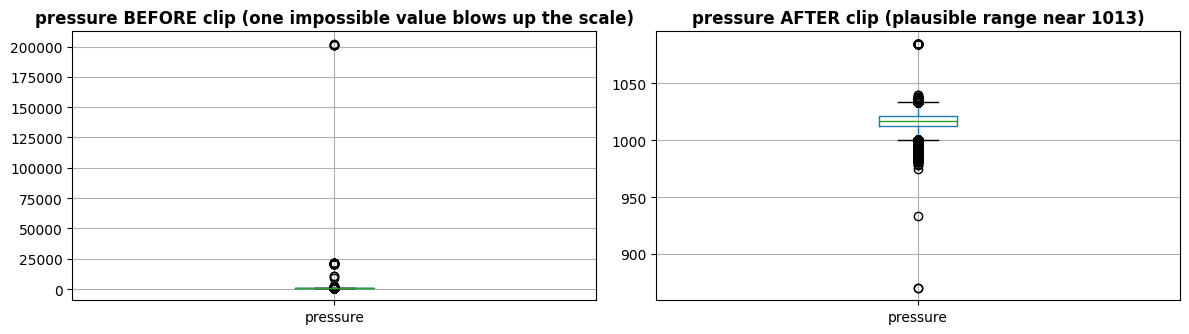

In [12]:
pc, ph = weather["pressure"].max(), df["pressure"].max()
wc, wh = weather["wind_speed"].max(), df["wind_speed"].max()
print(f"pressure: worst single city {pc:>10,.0f} hPa  ->  hourly mean still {ph:>9,.0f}   (real near 1013, the error PROPAGATED through the mean)")
print(f"wind    : worst single city {wc:>10.0f} m/s  ->  hourly mean only  {wh:>9.1f}   (storm near 30, the error was HIDDEN by the mean)")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
df.boxplot(column="pressure", ax=ax[0]); ax[0].set_title("pressure BEFORE clip (one impossible value blows up the scale)")
df["pressure"]   = df["pressure"].clip(870, 1085)   # fixed physical bounds, not learned, so no leakage
df["wind_speed"] = df["wind_speed"].clip(0, 40)
df.boxplot(column="pressure", ax=ax[1]); ax[1].set_title("pressure AFTER clip (plausible range near 1013)")
plt.suptitle(""); fig.tight_layout(); fig.savefig(IMG / "outliers.png", dpi=130); plt.show()

**Observe.** Which bad value survived the averaging, and which one was hidden? Why can the imputer not fix these?

**Answer:** The impossible pressure value survived the city averaging and still produced an extremely large hourly mean. The impossible wind-speed value was hidden because averaging across cities reduced its effect. The imputer cannot fix these values because they are present as numbers rather than missing values (NaN). Therefore, physically reasonable clipping limits are needed.

## 11. Split by time, never random
Shuffling lets the model peek at neighbouring hours, which inflates every score. **Your turn:** train up to 2016, validation 2017, test 2018.

In [14]:
# Convert UTC timestamps back to Spain local time for year-based splitting
local_time = df["time"].dt.tz_convert("Europe/Madrid")
year = local_time.dt.year

train_df = df[year <= 2016].copy()
val_df   = df[year == 2017].copy()
test_df  = df[year == 2018].copy()

for name, part in [
    ("train", train_df),
    ("val", val_df),
    ("test", test_df)
]:
    local_dates = part["time"].dt.tz_convert("Europe/Madrid")

    print(
        f"{name:5s} {part.shape[0]:6d}   "
        f"{local_dates.min().date()} -> {local_dates.max().date()}"
    )

train  17544   2015-01-01 -> 2016-12-31
val     8760   2017-01-01 -> 2017-12-31
test    8760   2018-01-01 -> 2018-12-31


**Observe.** What are the three sizes, and why must the test year stay untouched?

**Answer:** The training set contains 17,544 rows from 2015–2016, while the validation and test sets each contain 8,760 rows for 2017 and 2018. The test year must remain untouched during model development so that it provides an unbiased final evaluation on future unseen data. It must not be used for fitting, tuning or choosing the model.

## 12. Choosing a scaler
Scaling puts features on a comparable footing. Not every model needs it.

| Scaler | What it does | Good when |
|---|---|---|
| StandardScaler | mean 0, std 1 | linear / Ridge / neural nets, the usual default |
| MinMaxScaler | rescales to [0, 1] | bounded inputs, but one outlier squashes the rest |
| RobustScaler | centers on median, scales by the IQR | features still skewed or with outliers |
| none | leave as is | tree models (RF, GBM, XGBoost) do not need scaling |

Linear and gradient based models need scaling; tree based models do not, and scaling does not hurt them.

In [15]:
print(df[[TARGET, "temp", "price actual"]].describe().loc[["min", "max"]].round(1).to_string())
print("\nThe features live on very different scales (load in tens of thousands, temp in tens), so a linear model needs scaling.")

     total load actual  temp  price actual
min            18041.0  -1.2           9.3
max            41015.0  36.1         116.8

The features live on very different scales (load in tens of thousands, temp in tens), so a linear model needs scaling.


**Your choice.**
Scaler for a Ridge baseline = StandardScaler, because the numerical features have very different ranges. StandardScaler gives them a similar scale so that features with large numerical values do not dominate the Ridge model.

Do the tree models need scaling? No. Tree models divide data using feature thresholds, so they are not affected by features having different measurement scales. Scaling is therefore unnecessary for Random Forest, Gradient Boosting and XGBoost.

## 13. Fit transforms on train only
Anything that learns from data must learn on train only, then apply to validation and test. **Your turn:** fit the imputer and the chosen scaler on train, transform validation and test.

In [16]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
feat = [c for c in df.select_dtypes("number").columns if c not in {TARGET, REFERENCE, "target_filled"}]
imp, sc = SimpleImputer(strategy="median"), StandardScaler()
# Learn the medians and scaling statistics from training data only
X_train = sc.fit_transform(
    imp.fit_transform(train_df[feat])
)

# Apply the already-learned transformations
X_val = sc.transform(
    imp.transform(val_df[feat])
)

X_test = sc.transform(
    imp.transform(test_df[feat])
)
print("solar median  train:", round(train_df['generation solar'].median(), 1),
      "| all-data:", round(df['generation solar'].median(), 1), " <- fitting on all would leak val and test")

solar median  train: 629.0 | all-data: 616.0  <- fitting on all would leak val and test


**Observe.** Are the two medians the same? What does the difference tell you about fitting on all the data?

**Answer:** The two medians are different: the training-only median is 629.0 MW, while the median calculated from the full dataset is 616.0 MW. This shows that the validation and test years have a slightly different distribution. Fitting the imputer on all the data would allow future information to influence preprocessing, causing data leakage and making the evaluation less reliable.

## 14. Wrap it in a pipeline and save it
One fitted object gives the same transform for train, validation, test, and the FastAPI backend. We save it so the next notebook reloads it instead of retraining.

In [17]:
from sklearn.pipeline import Pipeline
import joblib
preprocess = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
preprocess.fit(train_df[feat])
joblib.dump({"pipeline": preprocess, "features": feat}, ROOT / "models" / "preprocess.joblib")
print("pipeline:", [n for n, _ in preprocess.steps], "| saved to models/preprocess.joblib")

pipeline: ['imputer', 'scaler'] | saved to models/preprocess.joblib


## 15. Leakage and availability audit
For each family, answer: available at prediction time? then give a use. This is the most important table of the day.

| Column or family | Available at prediction time? | Use |
|---|---|---|
| `total load actual` (target) | No, not for the future target hour | Use as the training label. Only past values may be used through safe lags such as t−24 and t−168. |
| `total load forecast` | Yes, it is published in advance | Keep only as a professional reference benchmark. Do not feed it directly into our model. |
| `generation *` (actual) |No, not for the future hour | Do not use directly. It may only be used after lagging it by at least 24 hours. |
| `forecast * day ahead` | Yes | Safe to use directly because these forecasts are available before the target hour. |
| `price day ahead` | Yes, if published before delivery | May be used as a feature with the timing assumption clearly documented. |
| `price actual` | No | Do not use directly for the future hour. Only lagged historical values would be safe. |
| weather (observed) | No, not for the future target hour | In this educational project, observed weather is used as a documented proxy for a day-ahead weather forecast. A real system should use forecasted weather. |
| calendar (hour, dow, month) | Yes | Safe to use directly because future dates, hours, weekdays and months are already known. |

**Observe.** Which families are safe to feed the model directly, and which are off limits because they carry the future?

**Answer:** Calendar features and variables that are genuinely published in advance, such as day-ahead weather, generation forecasts and possibly day-ahead prices, are safe to use directly. Future actual demand, generation, actual prices and observed future weather are not available at prediction time and must not be used directly. Historical actual values are only safe when converted into lags that respect the 24-hour forecasting horizon.

## 16. Done, next is feature engineering
Protocol built: clean structure, weather merged, visuals first, missing values and the scaler chosen with justification, the target handled without breaking continuity, outliers clipped, time split, train-only transforms, pipeline saved, leakage audited.

Next session: calendar features, lags (t-24, t-168), rolling statistics (past only), the 24 hour target, baselines, and the first models.